# Conditional Diffusion Model (DDPM)
### Butterfly Dataset — 75-class conditional image generation

Implements a Denoising Diffusion Probabilistic Model (DDPM) for butterfly image synthesis,
adapted from the `DiffusionModel` class structure in `exemplos_modelos/DIFFUSION.py`:
- Linear beta noise schedule (as suggested in DIFFUSION.py: *"some papers argue it can be linearly spaced!"*)
- UNet noise predictor with sinusoidal time embeddings (mirrors the per-timestep `network_tail` in `MLP`)
- Same `forward_process` / `reverse` / `sample` method names as in DIFFUSION.py
- DDPM training objective: MSE on predicted noise ε (replaces the KL loss used for 2-D data)

Class conditioning via `nn.Embedding` summed into the time embedding at every ResBlock,
following the same conditioning pattern used in 03_gan and 04_WGAN_GP.

In [31]:
import os, sys, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# ── Device setup ─────────────────────────────────────────────────────────
device = torch.device(
    "cuda"  if torch.cuda.is_available()  else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [32]:
sys.path.insert(0, os.path.abspath(".."))

from src.dataset import (
    ButterflyDataset, get_splits, build_label_map,
    get_train_transform, get_eval_transform, make_dataloader,
)
from src.utils import (
    save_checkpoint, load_checkpoint,
    visualize_grid, plot_losses,
    EarlyStopping, tensor_to_pil, denormalize,
)
from src.metrics import compute_fid, compute_inception_score

In [33]:
# ── Configuration ──────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath("..")
IMG_DIR      = os.path.join(BASE_DIR, "aca-butterflies", "train")
CSV_PATH     = os.path.join(BASE_DIR, "aca-butterflies", "train.csv")
SAVE_DIR     = os.path.join(BASE_DIR, "data", "generated", "diffusion")
MODEL_PATH   = os.path.join(BASE_DIR, "saved_models", "diffusion_unet.pth")
os.makedirs(SAVE_DIR, exist_ok=True)

IMAGE_SIZE   = 64       # matches TP2-students.ipynb
BATCH_SIZE   = 64       # RTX 5060 Laptop 8.5 GB VRAM
NUM_CLASSES  = 75
TIME_EMB_DIM = 256      # sinusoidal embedding dimension

# Diffusion hyperparameters — following DIFFUSION.py structure
T_STEPS      = 1000     # total diffusion timesteps (DIFFUSION.py uses N=40 for 2-D; 1000 is standard for images)
BETA_START   = 1e-4     # linear schedule start  (DIFFUSION.py: "linearly spaced!")
BETA_END     = 2e-2     # linear schedule end

NUM_EPOCHS          = 300
SAVE_EVERY          = 20
LR                  = 2e-4     # standard Adam lr for DDPM

# ── Classifier-Free Guidance (CFG) hyperparameters ────────────────────────
NULL_CLASS_IDX      = NUM_CLASSES   # index 75 = "null" class for unconditional pass
CFG_DROPOUT_RATE    = 0.1           # probability of dropping class label during training
CFG_GUIDANCE_SCALE  = 3.0           # guidance scale w (try 3.0, 4.0, 5.0 at generation time)

In [34]:
label_to_idx, idx_to_label = build_label_map(CSV_PATH)
num_classes = len(label_to_idx)

train_df, val_df, test_df = get_splits(CSV_PATH, train_ratio=0.70, val_ratio=0.15, seed=42)
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

train_set    = ButterflyDataset(train_df, IMG_DIR, label_to_idx,
                                transform=get_train_transform(IMAGE_SIZE))
train_loader = make_dataloader(train_set, BATCH_SIZE, shuffle=True)
print(f"Batches: {len(train_loader)}")

Train: 3,606  Val: 745  Test: 848
Batches: 57


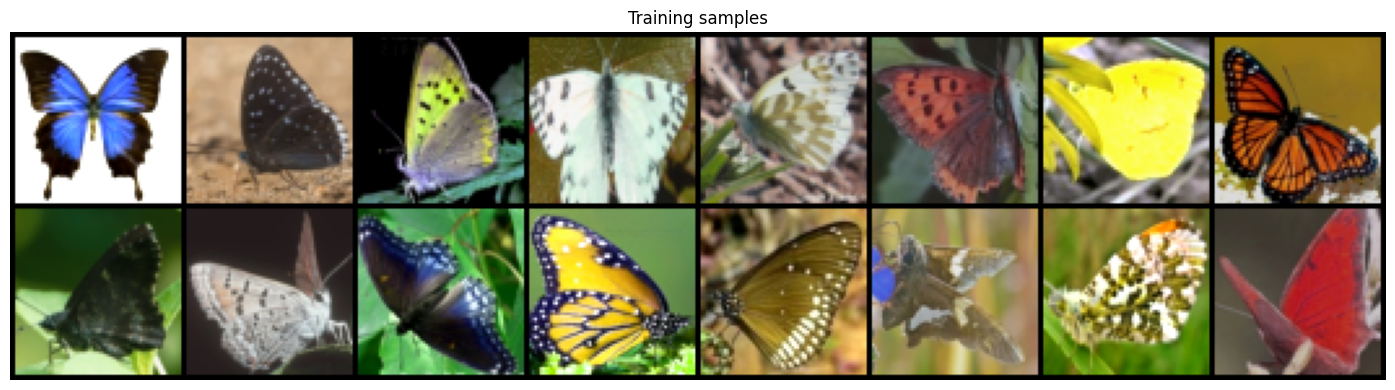

In [35]:
imgs, labs = next(iter(train_loader))
visualize_grid(imgs, labs, idx_to_label, n=16, nrow=8,
               title="Training samples", denorm=True)

## Model Architecture

### UNet (noise predictor)
Adapts the `MLP` noise-predictor concept from DIFFUSION.py to RGB images via a UNet:
- **Encoder** : 3→64→128→256 with `AvgPool2d` downsampling
- **Bottleneck**: 256→512→256
- **Decoder**  : skip connections + `ConvTranspose2d` upsampling → 3 output channels

**Conditioning**: sinusoidal time embedding + class embedding (both `TIME_EMB_DIM`)
are summed and injected into every `ResBlock` as a channel-wise shift,
mirroring how DIFFUSION.py injects timestep `t` into `MLP.network_tail[t]`.

### DiffusionModel
Wraps the UNet following the exact DIFFUSION.py class pattern:
- `forward_process(x0, t)` → q(x_t|x_0): adds noise at timestep t, returns (x_t, ε)
- `reverse(x_t, t, label)`  → p_θ(x_{t-1}|x_t): one denoising step
- `sample(n, label, device)` → full reverse chain from Gaussian noise → clean image

In [36]:
class SinusoidalPositionEmbeddings(nn.Module):
    """
    Sinusoidal timestep embeddings — converts scalar t into a fixed-frequency vector.
    Mirrors the per-timestep indexing in DIFFUSION.py's MLP (network_tail[t]).
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device   = time.device
        half_dim = self.dim // 2
        scale    = math.log(10000) / (half_dim - 1)
        freqs    = torch.exp(torch.arange(half_dim, device=device) * -scale)
        emb      = time[:, None].float() * freqs[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock(nn.Module):
    """
    Residual block with GroupNorm + SiLU activations and conditioning injection.
    The condition vector (time + class) is projected to `out_ch` and added channel-wise,
    implementing the affine shift described in the DDPM architecture literature.
    """
    def __init__(self, in_ch, out_ch, cond_dim, num_groups=8):
        super().__init__()
        # num_groups must divide the channel count; clamp for small in_ch (e.g. 3)
        ng1 = min(num_groups, in_ch)
        ng2 = min(num_groups, out_ch)
        self.cond_proj = nn.Linear(cond_dim, out_ch)
        self.block1    = nn.Sequential(
            nn.GroupNorm(ng1, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
        )
        self.block2    = nn.Sequential(
            nn.GroupNorm(ng2, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
        )
        self.res_conv  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, cond):
        h = self.block1(x)
        h = h + self.cond_proj(cond)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)


class SelfAttention(nn.Module):
    """
    Multi-head self-attention for global structure (e.g. wing symmetry).
    Applied at the 8×8 bottleneck where full spatial attention is cheap.
    Mirrors the global-context idea from DIFFUSION.py's latent diffusion context.
    """
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.mha      = nn.MultiheadAttention(channels, num_heads=4, batch_first=True)
        self.ln       = nn.LayerNorm(channels)

    def forward(self, x):
        B, C, H, W = x.shape
        # Flatten to (B, H*W, C) — every pixel attends to every other pixel
        x_flat       = x.view(B, C, H * W).transpose(1, 2)
        x_norm       = self.ln(x_flat)
        attn_out, _  = self.mha(x_norm, x_norm, x_norm)
        x_flat       = x_flat + attn_out            # residual connection
        return x_flat.transpose(1, 2).view(B, C, H, W)


class UNet(nn.Module):
    """
    Conditional UNet noise predictor for 64×64 RGB images.
    Input : noisy image (B, 3, 64, 64), timestep t (B,), class label (B,)
    Output: predicted noise ε (B, 3, 64, 64)
    """
    def __init__(self, num_classes=NUM_CLASSES, time_emb_dim=TIME_EMB_DIM):
        super().__init__()
        cond_dim = time_emb_dim

        # Time embedding: sinusoidal → 2-layer MLP (mirrors DIFFUSION.py's MLP structure)
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.GELU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )
        # Class embedding: +1 slot for the null class used in CFG
        self.class_emb = nn.Embedding(num_classes + 1, time_emb_dim)

        # ── Encoder ──────────────────────────────────────────────────────
        self.down1   = ResBlock(3,   64,  cond_dim)    # (B, 64,  64, 64)
        self.pool1   = nn.AvgPool2d(2)                 # → 32×32
        self.down2   = ResBlock(64,  128, cond_dim)    # (B, 128, 32, 32)
        self.pool2   = nn.AvgPool2d(2)                 # → 16×16
        self.down3   = ResBlock(128, 256, cond_dim)    # (B, 256, 16, 16)
        self.pool3   = nn.AvgPool2d(2)                 # → 8×8

        # ── Bottleneck (Self-Attention for global structure) ───────────────
        self.mid1    = ResBlock(256, 512, cond_dim)    # (B, 512, 8, 8)
        self.attn    = SelfAttention(512)              # global attention at 8×8
        self.mid2    = ResBlock(512, 256, cond_dim)    # (B, 256, 8, 8)

        # ── Decoder ───────────────────────────────────────────────────────
        self.up3     = nn.ConvTranspose2d(256, 256, 2, 2)               # → 16×16
        self.up3_res = ResBlock(256 + 256, 256, cond_dim)
        self.up2     = nn.ConvTranspose2d(256, 128, 2, 2)               # → 32×32
        self.up2_res = ResBlock(128 + 128, 128, cond_dim)
        self.up1     = nn.ConvTranspose2d(128,  64, 2, 2)               # → 64×64
        self.up1_res = ResBlock( 64 +  64,  64, cond_dim)

        # Output head
        self.out_norm = nn.GroupNorm(8, 64)
        self.out_conv = nn.Conv2d(64, 3, 1)

    def forward(self, x, t, label):
        # Combined condition: time embedding + class embedding (both TIME_EMB_DIM)
        cond = self.time_mlp(t) + self.class_emb(label)     # (B, cond_dim)

        # Encoder
        d1 = self.down1(x,               cond)   # (B, 64,  64, 64)
        d2 = self.down2(self.pool1(d1),  cond)   # (B, 128, 32, 32)
        d3 = self.down3(self.pool2(d2),  cond)   # (B, 256, 16, 16)

        # Bottleneck
        m  = self.mid1(self.pool3(d3),   cond)   # (B, 512,  8,  8)
        m  = self.attn(m)                         # global self-attention at 8×8
        m  = self.mid2(m,                cond)   # (B, 256,  8,  8)

        # Decoder with skip connections
        u3 = self.up3_res(torch.cat([self.up3(m),  d3], dim=1), cond)  # (B, 256, 16, 16)
        u2 = self.up2_res(torch.cat([self.up2(u3), d2], dim=1), cond)  # (B, 128, 32, 32)
        u1 = self.up1_res(torch.cat([self.up1(u2), d1], dim=1), cond)  # (B,  64, 64, 64)

        return self.out_conv(F.silu(self.out_norm(u1)))

In [37]:
class DiffusionModel(nn.Module):
    """
    DDPM wrapper — mirrors the DiffusionModel class in DIFFUSION.py.

    Forward process  : q(x_t | x_0) — adds noise progressively using alpha_bar
    Reverse process  : p_θ(x_{t-1}|x_t) — UNet predicts ε at each step
    Training objective: E[ ||ε - ε_θ(x_t, t, c)||² ]  (DDPM Eq. 14)

    Key variables match DIFFUSION.py naming:
        beta, alpha, alpha_bar, sigma2, n_steps
    """
    def __init__(self, model: nn.Module, n_steps=T_STEPS, device='cpu'):
        super().__init__()
        self.model   = model
        self.n_steps = n_steps

        # Linear beta schedule — DIFFUSION.py uses sigmoid-spaced betas but notes
        # "some papers argue that it can be linearly spaced!" — using linear here.
        self.beta      = torch.linspace(BETA_START, BETA_END, n_steps).to(device)
        self.alpha     = 1.0 - self.beta
        # alpha_bar: cumulative product — same as DIFFUSION.py alpha_bar
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)
        # sigma2 matches DIFFUSION.py: same value as beta
        self.sigma2    = self.beta

    # ── Forward process ───────────────────────────────────────────────────
    def forward_process(self, x0, t):
        """
        q(x_t | x_0) = N( sqrt(ᾱ_t)·x0,  (1-ᾱ_t)·I )

        Mirrors DIFFUSION.py forward_process: computes noisy x_t and true noise ε.
        t is a batch tensor of timestep indices (one per sample).
        Returns (x_t, ε).
        """
        alpha_bar_t = self.alpha_bar[t].view(-1, 1, 1, 1)
        noise       = torch.randn_like(x0)
        xt          = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1.0 - alpha_bar_t) * noise
        return xt, noise

    # ── DDPM denoising step (shared by reverse and sample_cfg) ────────────
    def _ddpm_step(self, xt, t: int, pred_noise):
        """
        One DDPM denoising step given a pre-computed noise prediction.
        Extracted so that both reverse() and sample_cfg() can reuse it
        without duplicating the posterior mean / variance formula.
        """
        beta_t      = self.beta[t]
        alpha_t     = self.alpha[t]
        alpha_bar_t = self.alpha_bar[t]

        # DDPM posterior mean (Eq. 11)
        mu = (1.0 / torch.sqrt(alpha_t)) * (
            xt - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * pred_noise
        )

        if t == 0:
            return mu

        # sigma2 = beta_t  (matches DIFFUSION.py: self.sigma2 = self.beta)
        sigma = torch.sqrt(beta_t)
        return mu + sigma * torch.randn_like(xt)

    # ── Reverse step ──────────────────────────────────────────────────────
    def reverse(self, xt, t: int, label):
        """
        One p_θ step: reconstruct x_{t-1} from x_t.
        Mirrors DIFFUSION.py reverse: predicts mu & sigma, then samples from them.
        t is a scalar integer.
        """
        t_tensor   = torch.full((xt.size(0),), t, dtype=torch.long, device=xt.device)
        pred_noise = self.model(xt, t_tensor, label)
        return self._ddpm_step(xt, t, pred_noise)

    # ── Standard sampling ─────────────────────────────────────────────────
    @torch.no_grad()
    def sample(self, n: int, label, device):
        """
        Full reverse chain: pure Gaussian noise → clean image.
        Mirrors DIFFUSION.py sample(): iterates reverse() from T-1 down to 0.
        """
        x = torch.randn(n, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
        for t in reversed(range(self.n_steps)):
            x = self.reverse(x, t, label)
        return x


@torch.no_grad()
def sample_cfg(unet, diffusion, labels, image_size=IMAGE_SIZE,
               guidance_scale=CFG_GUIDANCE_SCALE, device=device):
    """
    Classifier-Free Guidance sampling.
    Runs UNet twice per step — once with the real class label (conditional)
    and once with the null class (unconditional) — then combines:
        ε = ε_uncond + guidance_scale × (ε_cond − ε_uncond)
    Higher guidance_scale → more class-faithful images (try 3.0, 4.0, 5.0).
    """
    unet.eval()
    B             = labels.size(0)
    uncond_labels = torch.full_like(labels, NULL_CLASS_IDX)

    x = torch.randn(B, 3, image_size, image_size, device=device)

    for t_step in reversed(range(diffusion.n_steps)):
        t = torch.full((B,), t_step, dtype=torch.long, device=device)

        cond_noise   = unet(x, t, labels)
        uncond_noise = unet(x, t, uncond_labels)

        # CFG formula: steer prediction away from unconditional toward conditional
        pred_noise = uncond_noise + guidance_scale * (cond_noise - uncond_noise)

        x = diffusion._ddpm_step(x, t_step, pred_noise)

    return x

In [38]:
# ── Instantiate ───────────────────────────────────────────────────────────
unet      = UNet(NUM_CLASSES, TIME_EMB_DIM).to(device)
diffusion = DiffusionModel(unet, T_STEPS, device).to(device)

print(f"UNet parameters: {sum(p.numel() for p in unet.parameters()):,}")

optimizer = optim.Adam(unet.parameters(), lr=LR)

UNet parameters: 11,319,817


[1/300][0/57]  Loss: 1.1164
[1/300][50/57]  Loss: 0.1016
[2/300][0/57]  Loss: 0.0685
[2/300][50/57]  Loss: 0.0499
[3/300][0/57]  Loss: 0.1148
[3/300][50/57]  Loss: 0.1109
[4/300][0/57]  Loss: 0.0675
[4/300][50/57]  Loss: 0.0599
[5/300][0/57]  Loss: 0.0696
[5/300][50/57]  Loss: 0.0424
[6/300][0/57]  Loss: 0.0525
[6/300][50/57]  Loss: 0.0512
[7/300][0/57]  Loss: 0.0588
[7/300][50/57]  Loss: 0.0336
[8/300][0/57]  Loss: 0.0535
[8/300][50/57]  Loss: 0.0602
[9/300][0/57]  Loss: 0.0358
[9/300][50/57]  Loss: 0.0700
[10/300][0/57]  Loss: 0.0491
[10/300][50/57]  Loss: 0.0499
[11/300][0/57]  Loss: 0.0233
[11/300][50/57]  Loss: 0.0452
[12/300][0/57]  Loss: 0.0340
[12/300][50/57]  Loss: 0.0482
[13/300][0/57]  Loss: 0.0567
[13/300][50/57]  Loss: 0.0538
[14/300][0/57]  Loss: 0.0510
[14/300][50/57]  Loss: 0.0310
[15/300][0/57]  Loss: 0.0324
[15/300][50/57]  Loss: 0.0402
[16/300][0/57]  Loss: 0.0435
[16/300][50/57]  Loss: 0.0468
[17/300][0/57]  Loss: 0.0263
[17/300][50/57]  Loss: 0.0393
[18/300][0/57] 

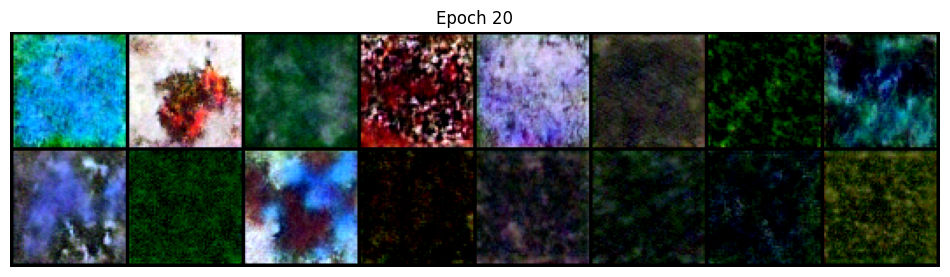

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 20
[21/300][0/57]  Loss: 0.0585
[21/300][50/57]  Loss: 0.0342
[22/300][0/57]  Loss: 0.0303
[22/300][50/57]  Loss: 0.0364
[23/300][0/57]  Loss: 0.0448
[23/300][50/57]  Loss: 0.0427
[24/300][0/57]  Loss: 0.0435
[24/300][50/57]  Loss: 0.0300
[25/300][0/57]  Loss: 0.0303
[25/300][50/57]  Loss: 0.0333
[26/300][0/57]  Loss: 0.0538
[26/300][50/57]  Loss: 0.0340
[27/300][0/57]  Loss: 0.0572
[27/300][50/57]  Loss: 0.0242
[28/300][0/57]  Loss: 0.0353
[28/300][50/57]  Loss: 0.0390
[29/300][0/57]  Loss: 0.0528
[29/300][50/57]  Loss: 0.0341
[30/300][0/57]  Loss: 0.0365
[30/300][50/57]  Loss: 0.0486
[31/300][0/57]  Loss: 0.0382
[31/300][50/57]  Loss: 0.0241
[32/300][0/57]  Loss: 0.0357
[32/300][50/57]  Loss: 0.0400
[33/300][0/57]  Loss: 0.0593
[33/300][50/57]  Loss: 0.0359
[34/300][0/57]  Loss: 0.0228
[34/300][50/57]  Loss: 0.0359
[35/300][0/57]  Loss: 0.0374
[35/300][50/57]  Loss: 0.

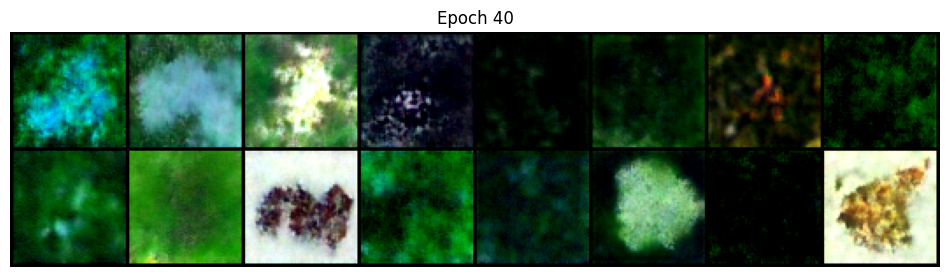

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 40
[41/300][0/57]  Loss: 0.0558
[41/300][50/57]  Loss: 0.0433
[42/300][0/57]  Loss: 0.0222
[42/300][50/57]  Loss: 0.0291
[43/300][0/57]  Loss: 0.0511
[43/300][50/57]  Loss: 0.0284
[44/300][0/57]  Loss: 0.0307
[44/300][50/57]  Loss: 0.0294
[45/300][0/57]  Loss: 0.0401
[45/300][50/57]  Loss: 0.0406
[46/300][0/57]  Loss: 0.0389
[46/300][50/57]  Loss: 0.0445
[47/300][0/57]  Loss: 0.0354
[47/300][50/57]  Loss: 0.0280
[48/300][0/57]  Loss: 0.0364
[48/300][50/57]  Loss: 0.0424
[49/300][0/57]  Loss: 0.0305
[49/300][50/57]  Loss: 0.0338
[50/300][0/57]  Loss: 0.0365
[50/300][50/57]  Loss: 0.0215
[51/300][0/57]  Loss: 0.0356
[51/300][50/57]  Loss: 0.0309
[52/300][0/57]  Loss: 0.0259
[52/300][50/57]  Loss: 0.0447
[53/300][0/57]  Loss: 0.0186
[53/300][50/57]  Loss: 0.0615
[54/300][0/57]  Loss: 0.0442
[54/300][50/57]  Loss: 0.0289
[55/300][0/57]  Loss: 0.0451
[55/300][50/57]  Loss: 0.

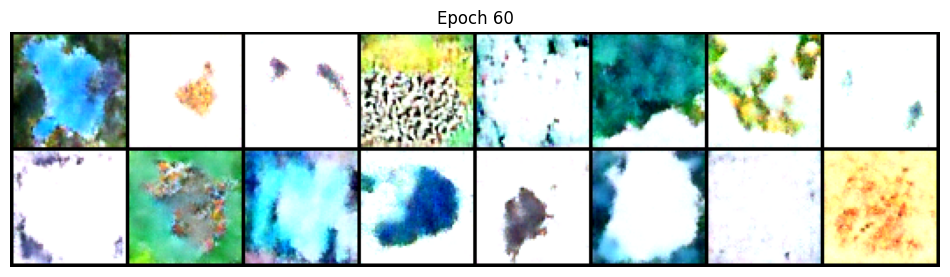

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 60
[61/300][0/57]  Loss: 0.0232
[61/300][50/57]  Loss: 0.0283
[62/300][0/57]  Loss: 0.0391
[62/300][50/57]  Loss: 0.0190
[63/300][0/57]  Loss: 0.0516
[63/300][50/57]  Loss: 0.0214
[64/300][0/57]  Loss: 0.0308
[64/300][50/57]  Loss: 0.0559
[65/300][0/57]  Loss: 0.0514
[65/300][50/57]  Loss: 0.0349
[66/300][0/57]  Loss: 0.0556
[66/300][50/57]  Loss: 0.0307
[67/300][0/57]  Loss: 0.0404
[67/300][50/57]  Loss: 0.0296
[68/300][0/57]  Loss: 0.0371
[68/300][50/57]  Loss: 0.0218
[69/300][0/57]  Loss: 0.0480
[69/300][50/57]  Loss: 0.0464
[70/300][0/57]  Loss: 0.0382
[70/300][50/57]  Loss: 0.0357
[71/300][0/57]  Loss: 0.0392
[71/300][50/57]  Loss: 0.0320
[72/300][0/57]  Loss: 0.0361
[72/300][50/57]  Loss: 0.0362
[73/300][0/57]  Loss: 0.0261
[73/300][50/57]  Loss: 0.0251
[74/300][0/57]  Loss: 0.0306
[74/300][50/57]  Loss: 0.0273
[75/300][0/57]  Loss: 0.0249
[75/300][50/57]  Loss: 0.

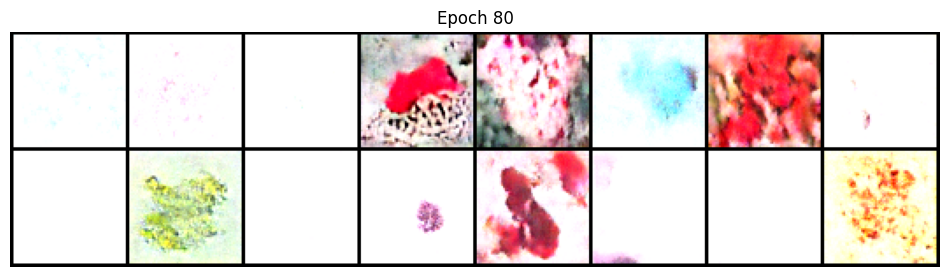

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 80
[81/300][0/57]  Loss: 0.0337
[81/300][50/57]  Loss: 0.0337
[82/300][0/57]  Loss: 0.0344
[82/300][50/57]  Loss: 0.0330
[83/300][0/57]  Loss: 0.0200
[83/300][50/57]  Loss: 0.0200
[84/300][0/57]  Loss: 0.0427
[84/300][50/57]  Loss: 0.0273
[85/300][0/57]  Loss: 0.0487
[85/300][50/57]  Loss: 0.0406
[86/300][0/57]  Loss: 0.0366
[86/300][50/57]  Loss: 0.0240
[87/300][0/57]  Loss: 0.0233
[87/300][50/57]  Loss: 0.0289
[88/300][0/57]  Loss: 0.0383
[88/300][50/57]  Loss: 0.0231
[89/300][0/57]  Loss: 0.0361
[89/300][50/57]  Loss: 0.0324
[90/300][0/57]  Loss: 0.0410
[90/300][50/57]  Loss: 0.0391
[91/300][0/57]  Loss: 0.0259
[91/300][50/57]  Loss: 0.0205
[92/300][0/57]  Loss: 0.0366
[92/300][50/57]  Loss: 0.0241
[93/300][0/57]  Loss: 0.0514
[93/300][50/57]  Loss: 0.0388
[94/300][0/57]  Loss: 0.0226
[94/300][50/57]  Loss: 0.0158
[95/300][0/57]  Loss: 0.0353
[95/300][50/57]  Loss: 0.

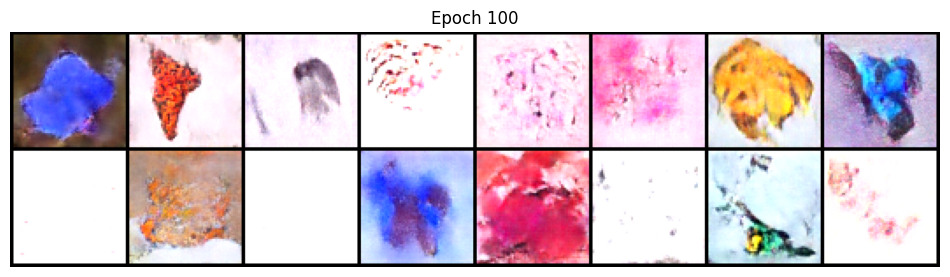

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 100
[101/300][0/57]  Loss: 0.0345
[101/300][50/57]  Loss: 0.0198
[102/300][0/57]  Loss: 0.0352
[102/300][50/57]  Loss: 0.0450
[103/300][0/57]  Loss: 0.0301
[103/300][50/57]  Loss: 0.0449
[104/300][0/57]  Loss: 0.0395
[104/300][50/57]  Loss: 0.0343
[105/300][0/57]  Loss: 0.0356
[105/300][50/57]  Loss: 0.0303
[106/300][0/57]  Loss: 0.0183
[106/300][50/57]  Loss: 0.0203
[107/300][0/57]  Loss: 0.0447
[107/300][50/57]  Loss: 0.0356
[108/300][0/57]  Loss: 0.0245
[108/300][50/57]  Loss: 0.0259
[109/300][0/57]  Loss: 0.0267
[109/300][50/57]  Loss: 0.0429
[110/300][0/57]  Loss: 0.0266
[110/300][50/57]  Loss: 0.0454
[111/300][0/57]  Loss: 0.0414
[111/300][50/57]  Loss: 0.0230
[112/300][0/57]  Loss: 0.0248
[112/300][50/57]  Loss: 0.0209
[113/300][0/57]  Loss: 0.0280
[113/300][50/57]  Loss: 0.0160
[114/300][0/57]  Loss: 0.0176
[114/300][50/57]  Loss: 0.0366
[115/300][0/57]  Loss: 0.

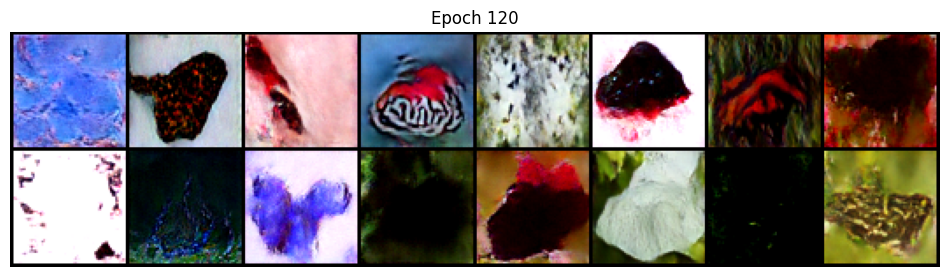

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 120
[121/300][0/57]  Loss: 0.0523
[121/300][50/57]  Loss: 0.0452
[122/300][0/57]  Loss: 0.0278
[122/300][50/57]  Loss: 0.0245
[123/300][0/57]  Loss: 0.0172
[123/300][50/57]  Loss: 0.0353
[124/300][0/57]  Loss: 0.0274
[124/300][50/57]  Loss: 0.0281
[125/300][0/57]  Loss: 0.0270
[125/300][50/57]  Loss: 0.0306
[126/300][0/57]  Loss: 0.0378
[126/300][50/57]  Loss: 0.0318
[127/300][0/57]  Loss: 0.0355
[127/300][50/57]  Loss: 0.0495
[128/300][0/57]  Loss: 0.0477
[128/300][50/57]  Loss: 0.0173
[129/300][0/57]  Loss: 0.0297
[129/300][50/57]  Loss: 0.0251
[130/300][0/57]  Loss: 0.0323
[130/300][50/57]  Loss: 0.0282
[131/300][0/57]  Loss: 0.0296
[131/300][50/57]  Loss: 0.0278
[132/300][0/57]  Loss: 0.0286
[132/300][50/57]  Loss: 0.0234
[133/300][0/57]  Loss: 0.0236
[133/300][50/57]  Loss: 0.0452
[134/300][0/57]  Loss: 0.0292
[134/300][50/57]  Loss: 0.0430
[135/300][0/57]  Loss: 0.

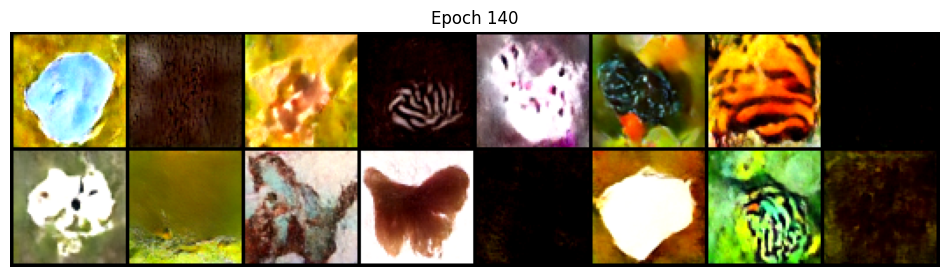

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 140
[141/300][0/57]  Loss: 0.0352
[141/300][50/57]  Loss: 0.0509
[142/300][0/57]  Loss: 0.0190
[142/300][50/57]  Loss: 0.0415
[143/300][0/57]  Loss: 0.0397
[143/300][50/57]  Loss: 0.0285
[144/300][0/57]  Loss: 0.0339
[144/300][50/57]  Loss: 0.0239
[145/300][0/57]  Loss: 0.0296
[145/300][50/57]  Loss: 0.0380
[146/300][0/57]  Loss: 0.0219
[146/300][50/57]  Loss: 0.0252
[147/300][0/57]  Loss: 0.0236
[147/300][50/57]  Loss: 0.0498
[148/300][0/57]  Loss: 0.0245
[148/300][50/57]  Loss: 0.0370
[149/300][0/57]  Loss: 0.0191
[149/300][50/57]  Loss: 0.0265
[150/300][0/57]  Loss: 0.0268
[150/300][50/57]  Loss: 0.0389
[151/300][0/57]  Loss: 0.0296
[151/300][50/57]  Loss: 0.0266
[152/300][0/57]  Loss: 0.0416
[152/300][50/57]  Loss: 0.0357
[153/300][0/57]  Loss: 0.0305
[153/300][50/57]  Loss: 0.0265
[154/300][0/57]  Loss: 0.0352
[154/300][50/57]  Loss: 0.0335
[155/300][0/57]  Loss: 0.

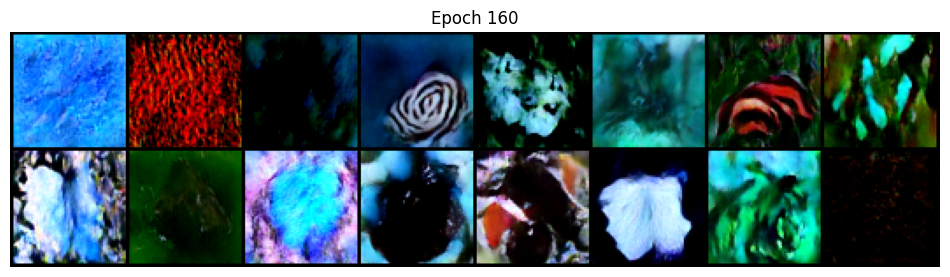

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 160
[161/300][0/57]  Loss: 0.0297
[161/300][50/57]  Loss: 0.0247
[162/300][0/57]  Loss: 0.0165
[162/300][50/57]  Loss: 0.0289
[163/300][0/57]  Loss: 0.0224
[163/300][50/57]  Loss: 0.0216
[164/300][0/57]  Loss: 0.0260
[164/300][50/57]  Loss: 0.0291
[165/300][0/57]  Loss: 0.0451
[165/300][50/57]  Loss: 0.0405
[166/300][0/57]  Loss: 0.0215
[166/300][50/57]  Loss: 0.0221
[167/300][0/57]  Loss: 0.0355
[167/300][50/57]  Loss: 0.0299
[168/300][0/57]  Loss: 0.0485
[168/300][50/57]  Loss: 0.0256
[169/300][0/57]  Loss: 0.0348
[169/300][50/57]  Loss: 0.0344
[170/300][0/57]  Loss: 0.0303
[170/300][50/57]  Loss: 0.0166
[171/300][0/57]  Loss: 0.0275
[171/300][50/57]  Loss: 0.0352
[172/300][0/57]  Loss: 0.0292
[172/300][50/57]  Loss: 0.0383
[173/300][0/57]  Loss: 0.0439
[173/300][50/57]  Loss: 0.0310
[174/300][0/57]  Loss: 0.0236
[174/300][50/57]  Loss: 0.0175
[175/300][0/57]  Loss: 0.

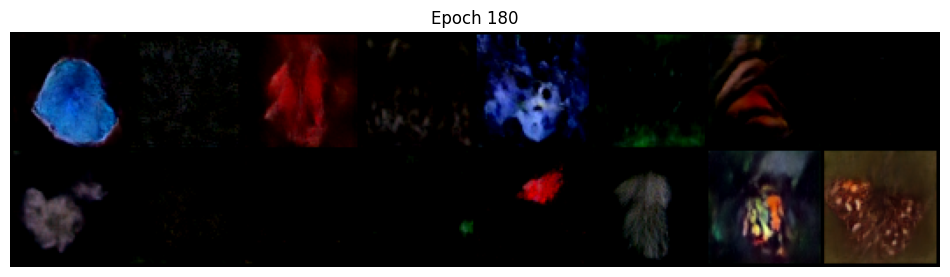

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 180
[181/300][0/57]  Loss: 0.0313
[181/300][50/57]  Loss: 0.0351
[182/300][0/57]  Loss: 0.0332
[182/300][50/57]  Loss: 0.0320
[183/300][0/57]  Loss: 0.0216
[183/300][50/57]  Loss: 0.0273
[184/300][0/57]  Loss: 0.0289
[184/300][50/57]  Loss: 0.0229
[185/300][0/57]  Loss: 0.0324
[185/300][50/57]  Loss: 0.0199
[186/300][0/57]  Loss: 0.0288
[186/300][50/57]  Loss: 0.0247
[187/300][0/57]  Loss: 0.0366
[187/300][50/57]  Loss: 0.0370
[188/300][0/57]  Loss: 0.0422
[188/300][50/57]  Loss: 0.0396
[189/300][0/57]  Loss: 0.0382
[189/300][50/57]  Loss: 0.0399
[190/300][0/57]  Loss: 0.0298
[190/300][50/57]  Loss: 0.0195
[191/300][0/57]  Loss: 0.0255
[191/300][50/57]  Loss: 0.0208
[192/300][0/57]  Loss: 0.0360
[192/300][50/57]  Loss: 0.0226
[193/300][0/57]  Loss: 0.0239
[193/300][50/57]  Loss: 0.0349
[194/300][0/57]  Loss: 0.0256
[194/300][50/57]  Loss: 0.0417
[195/300][0/57]  Loss: 0.

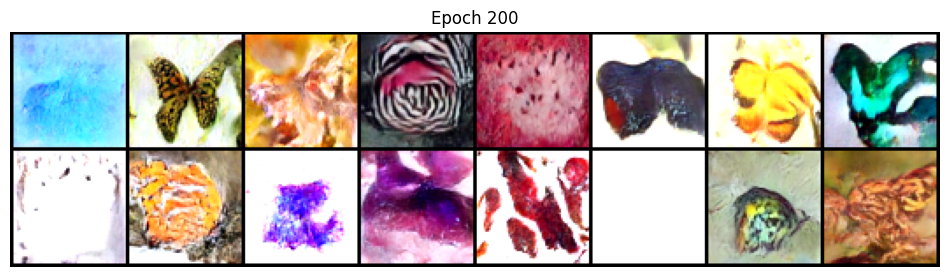

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 200
[201/300][0/57]  Loss: 0.0569
[201/300][50/57]  Loss: 0.0309
[202/300][0/57]  Loss: 0.0216
[202/300][50/57]  Loss: 0.0250
[203/300][0/57]  Loss: 0.0424
[203/300][50/57]  Loss: 0.0373
[204/300][0/57]  Loss: 0.0458
[204/300][50/57]  Loss: 0.0462
[205/300][0/57]  Loss: 0.0358
[205/300][50/57]  Loss: 0.0351
[206/300][0/57]  Loss: 0.0254
[206/300][50/57]  Loss: 0.0228
[207/300][0/57]  Loss: 0.0366
[207/300][50/57]  Loss: 0.0192
[208/300][0/57]  Loss: 0.0260
[208/300][50/57]  Loss: 0.0280
[209/300][0/57]  Loss: 0.0295
[209/300][50/57]  Loss: 0.0406
[210/300][0/57]  Loss: 0.0270
[210/300][50/57]  Loss: 0.0477
[211/300][0/57]  Loss: 0.0284
[211/300][50/57]  Loss: 0.0403
[212/300][0/57]  Loss: 0.0390
[212/300][50/57]  Loss: 0.0298
[213/300][0/57]  Loss: 0.0296
[213/300][50/57]  Loss: 0.0254
[214/300][0/57]  Loss: 0.0188
[214/300][50/57]  Loss: 0.0294
[215/300][0/57]  Loss: 0.

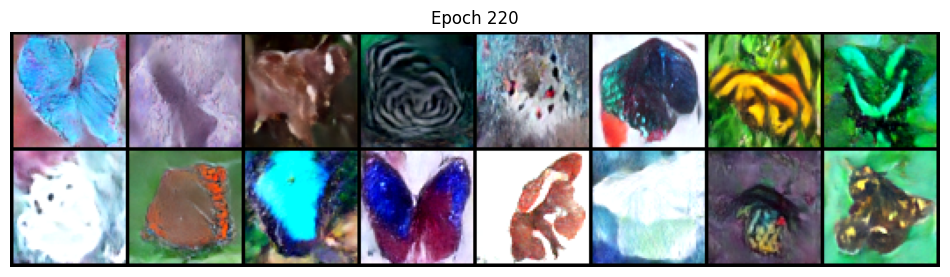

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 220
[221/300][0/57]  Loss: 0.0301
[221/300][50/57]  Loss: 0.0255
[222/300][0/57]  Loss: 0.0422
[222/300][50/57]  Loss: 0.0188
[223/300][0/57]  Loss: 0.0371
[223/300][50/57]  Loss: 0.0362
[224/300][0/57]  Loss: 0.0238
[224/300][50/57]  Loss: 0.0294
[225/300][0/57]  Loss: 0.0431
[225/300][50/57]  Loss: 0.0203
[226/300][0/57]  Loss: 0.0258
[226/300][50/57]  Loss: 0.0285
[227/300][0/57]  Loss: 0.0306
[227/300][50/57]  Loss: 0.0455
[228/300][0/57]  Loss: 0.0258
[228/300][50/57]  Loss: 0.0234
[229/300][0/57]  Loss: 0.0260
[229/300][50/57]  Loss: 0.0369
[230/300][0/57]  Loss: 0.0375
[230/300][50/57]  Loss: 0.0365
[231/300][0/57]  Loss: 0.0363
[231/300][50/57]  Loss: 0.0398
[232/300][0/57]  Loss: 0.0332
[232/300][50/57]  Loss: 0.0316
[233/300][0/57]  Loss: 0.0180
[233/300][50/57]  Loss: 0.0250
[234/300][0/57]  Loss: 0.0308
[234/300][50/57]  Loss: 0.0276
[235/300][0/57]  Loss: 0.

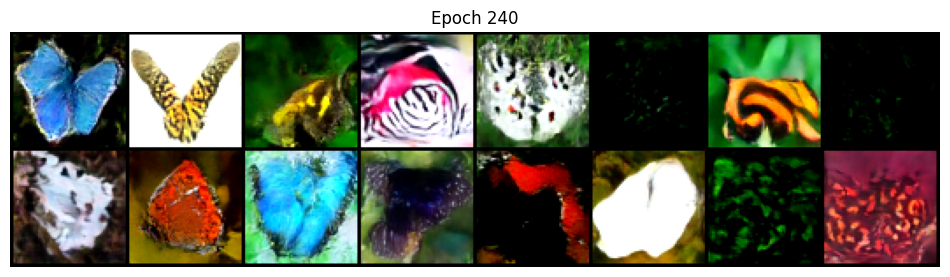

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 240
[241/300][0/57]  Loss: 0.0354
[241/300][50/57]  Loss: 0.0493
[242/300][0/57]  Loss: 0.0179
[242/300][50/57]  Loss: 0.0291
[243/300][0/57]  Loss: 0.0336
[243/300][50/57]  Loss: 0.0216
[244/300][0/57]  Loss: 0.0185
[244/300][50/57]  Loss: 0.0255
[245/300][0/57]  Loss: 0.0361
[245/300][50/57]  Loss: 0.0322
[246/300][0/57]  Loss: 0.0378
[246/300][50/57]  Loss: 0.0313
[247/300][0/57]  Loss: 0.0339
[247/300][50/57]  Loss: 0.0272
[248/300][0/57]  Loss: 0.0273
[248/300][50/57]  Loss: 0.0222
[249/300][0/57]  Loss: 0.0276
[249/300][50/57]  Loss: 0.0179
[250/300][0/57]  Loss: 0.0222
[250/300][50/57]  Loss: 0.0161
[251/300][0/57]  Loss: 0.0354
[251/300][50/57]  Loss: 0.0515
[252/300][0/57]  Loss: 0.0335
[252/300][50/57]  Loss: 0.0405
[253/300][0/57]  Loss: 0.0194
[253/300][50/57]  Loss: 0.0323
[254/300][0/57]  Loss: 0.0221
[254/300][50/57]  Loss: 0.0351
[255/300][0/57]  Loss: 0.

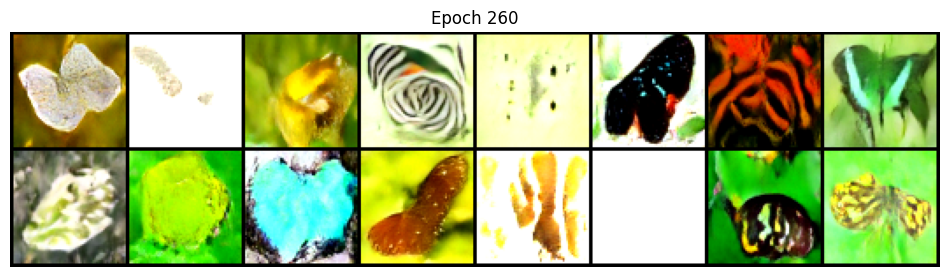

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 260
[261/300][0/57]  Loss: 0.0268
[261/300][50/57]  Loss: 0.0180
[262/300][0/57]  Loss: 0.0170
[262/300][50/57]  Loss: 0.0236
[263/300][0/57]  Loss: 0.0356
[263/300][50/57]  Loss: 0.0186
[264/300][0/57]  Loss: 0.0324
[264/300][50/57]  Loss: 0.0354
[265/300][0/57]  Loss: 0.0320
[265/300][50/57]  Loss: 0.0285
[266/300][0/57]  Loss: 0.0294
[266/300][50/57]  Loss: 0.0302
[267/300][0/57]  Loss: 0.0235
[267/300][50/57]  Loss: 0.0403
[268/300][0/57]  Loss: 0.0165
[268/300][50/57]  Loss: 0.0376
[269/300][0/57]  Loss: 0.0343
[269/300][50/57]  Loss: 0.0286
[270/300][0/57]  Loss: 0.0280
[270/300][50/57]  Loss: 0.0247
[271/300][0/57]  Loss: 0.0341
[271/300][50/57]  Loss: 0.0426
[272/300][0/57]  Loss: 0.0354
[272/300][50/57]  Loss: 0.0263
[273/300][0/57]  Loss: 0.0352
[273/300][50/57]  Loss: 0.0141
[274/300][0/57]  Loss: 0.0181
[274/300][50/57]  Loss: 0.0251
[275/300][0/57]  Loss: 0.

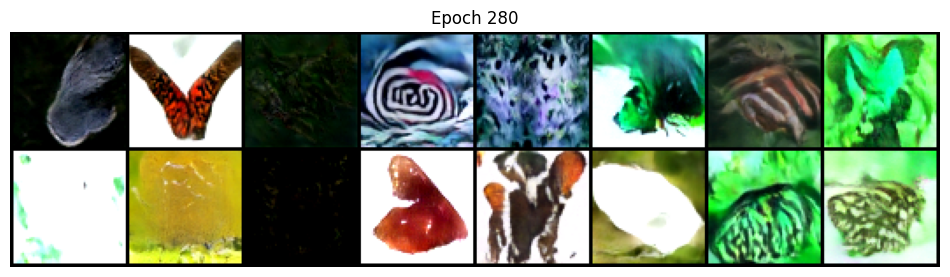

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 280
[281/300][0/57]  Loss: 0.0306
[281/300][50/57]  Loss: 0.0246
[282/300][0/57]  Loss: 0.0358
[282/300][50/57]  Loss: 0.0383
[283/300][0/57]  Loss: 0.0159
[283/300][50/57]  Loss: 0.0349
[284/300][0/57]  Loss: 0.0295
[284/300][50/57]  Loss: 0.0200
[285/300][0/57]  Loss: 0.0256
[285/300][50/57]  Loss: 0.0415
[286/300][0/57]  Loss: 0.0289
[286/300][50/57]  Loss: 0.0450
[287/300][0/57]  Loss: 0.0366
[287/300][50/57]  Loss: 0.0253
[288/300][0/57]  Loss: 0.0271
[288/300][50/57]  Loss: 0.0333
[289/300][0/57]  Loss: 0.0258
[289/300][50/57]  Loss: 0.0309
[290/300][0/57]  Loss: 0.0195
[290/300][50/57]  Loss: 0.0241
[291/300][0/57]  Loss: 0.0308
[291/300][50/57]  Loss: 0.0201
[292/300][0/57]  Loss: 0.0340
[292/300][50/57]  Loss: 0.0326
[293/300][0/57]  Loss: 0.0456
[293/300][50/57]  Loss: 0.0287
[294/300][0/57]  Loss: 0.0308
[294/300][50/57]  Loss: 0.0176
[295/300][0/57]  Loss: 0.

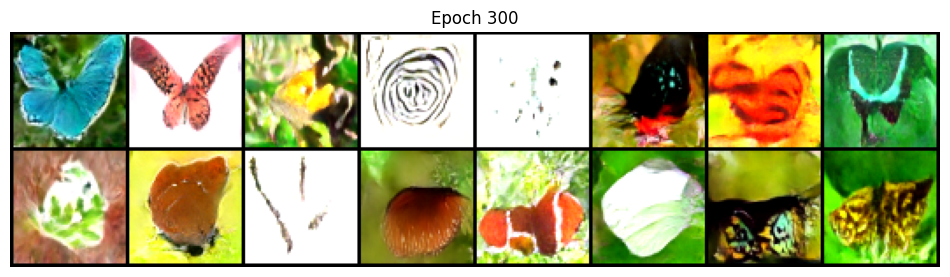

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
Checkpoint saved at epoch 300
Training complete.


In [39]:
losses = []

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0

    for i, (data, labels) in enumerate(train_loader):
        x0  = data.to(device)
        lbl = labels.to(device)

        # ── CFG label dropout: 10% of labels → null class ─────────────────
        mask = torch.rand(lbl.size(0), device=device) < CFG_DROPOUT_RATE
        lbl  = lbl.masked_fill(mask, NULL_CLASS_IDX)

        # 1. Sample a random timestep t for each image in the batch
        t = torch.randint(0, T_STEPS, (x0.size(0),), device=device)

        # 2. Forward process: add noise  (mirrors DIFFUSION.py train() step 1)
        xt, noise = diffusion.forward_process(x0, t)

        # 3. Predict noise via UNet  (mirrors DIFFUSION.py train() step 2)
        pred_noise = unet(xt, t, lbl)

        # 4. DDPM loss: MSE on noise (replaces KL used in DIFFUSION.py for 2-D data)
        loss = F.mse_loss(pred_noise, noise)

        # 5. Backprop and optimiser step  (mirrors DIFFUSION.py train() step 3)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if i % 50 == 0:
            print(f"[{epoch+1}/{NUM_EPOCHS}][{i}/{len(train_loader)}]  Loss: {loss.item():.4f}")

    losses.append(epoch_loss / len(train_loader))

    # ── Visualise generated samples every SAVE_EVERY epochs ──────────────
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        unet.eval()
        with torch.no_grad():
            sample_lbl  = torch.arange(min(16, NUM_CLASSES), device=device)
            fake_sample = sample_cfg(unet, diffusion, sample_lbl,
                                     guidance_scale=CFG_GUIDANCE_SCALE, device=device)
            fake_sample = ((fake_sample.cpu() + 1) * 0.5).clamp(0, 1)

        grid = make_grid(fake_sample, nrow=8, padding=2)
        plt.figure(figsize=(12, 6))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.axis("off")
        plt.title(f"Epoch {epoch+1}")
        plt.show()
        unet.train()

        save_checkpoint(unet, MODEL_PATH, epoch=epoch + 1)
        print(f"Checkpoint saved at epoch {epoch+1}")

print("Training complete.")

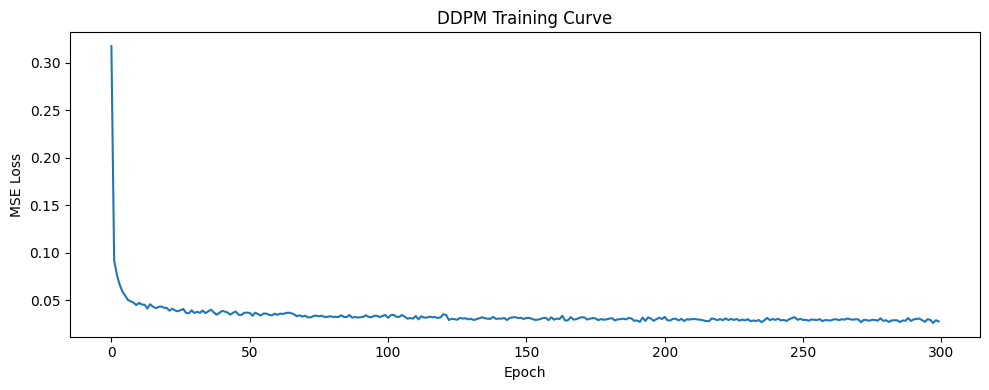

In [40]:
# ── Plot loss curve  (mirrors DIFFUSION.py train() loss tracking) ─────────
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DDPM Training Curve")
plt.tight_layout()
plt.show()

In [41]:
# ── Generate images per class to balance the dataset ──────────────────────
load_checkpoint(MODEL_PATH, unet, device)
unet = unet.to(device)
unet.eval()

class_counts     = Counter(train_df["label"].tolist())
TARGET_PER_CLASS = max(class_counts.values())

generated_records = []
with torch.no_grad():
    for class_name, class_idx in label_to_idx.items():
        existing  = class_counts.get(class_name, 0)
        n_gen     = max(0, TARGET_PER_CLASS - existing)
        if n_gen == 0:
            continue

        all_gen   = []
        remaining = n_gen
        while remaining > 0:
            batch_n = min(remaining, BATCH_SIZE)
            lbl     = torch.full((batch_n,), class_idx, dtype=torch.long, device=device)
            gen     = sample_cfg(unet, diffusion, lbl,
                                 guidance_scale=CFG_GUIDANCE_SCALE, device=device).cpu()  # (B,3,64,64) in [-1,1]
            all_gen.append(gen)
            remaining -= batch_n

        gen_imgs = torch.cat(all_gen, dim=0)
        gen_imgs = (gen_imgs * 0.5 + 0.5).clamp(0, 1)   # → [0,1]

        for j, img_t in enumerate(gen_imgs):
            fname = f"diffusion_{class_idx:03d}_{j:04d}.jpg"
            tensor_to_pil(img_t).save(os.path.join(SAVE_DIR, fname))
            generated_records.append({
                "filename": fname,
                "label":    class_name,
                "img_dir":  SAVE_DIR,
            })

        print(f"  [{class_idx:02d}] {class_name}: generated {n_gen}")

gen_df = pd.DataFrame(generated_records)
gen_df.to_csv(os.path.join(SAVE_DIR, "generated.csv"), index=False)
print(f"\nTotal generated: {len(gen_df):,}  |  CSV saved.")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\diffusion_unet.pth
  [00] ADONIS: generated 24
  [01] AFRICAN GIANT SWALLOWTAIL: generated 31
  [02] AMERICAN SNOOT: generated 32
  [03] AN 88: generated 26
  [04] APPOLLO: generated 23
  [05] ATALA: generated 17
  [06] BANDED ORANGE HELICONIAN: generated 20
  [07] BANDED PEACOCK: generated 27
  [08] BECKERS WHITE: generated 28
  [09] BLACK HAIRSTREAK: generated 26
  [10] BLUE MORPHO: generated 31
  [11] BLUE SPOTTED CROW: generated 25
  [12] BROWN SIPROETA: generated 18
  [13] CABBAGE WHITE: generated 23
  [14] CAIRNS BIRDWING: generated 27
  [15] CHECQUERED SKIPPER: generated 20
  [16] CHESTNUT: generated 26
  [17] CLEOPATRA: generated 22
  [18] CLODIUS PARNASSIAN: generated 24
  [19] CLOUDED SULPHUR: generated 22
  [20] COMMON BANDED AWL: generated 24
  [21] COMMON WOOD-NYMPH: generated 23
  [22] COPPER TAIL: generated 21
  [23] CRECENT: generated 20
  [24] CRIMSON PATCH: generated 33
  [25] DANAID EGGFLY: gene

## Evaluation of Generative Quality

FID and IS computed globally (all classes) — same protocol as cVAE, GAN, and WGAN-GP notebooks.
SSIM is omitted (outputs are not reconstruction-paired with real images).

In [42]:
def collect_tensor(loader):
    batches = [imgs for imgs, _ in loader]
    return torch.cat(batches, dim=0)


print("Collecting real images…")
real_imgs = collect_tensor(train_loader)

print("Collecting diffusion-generated images…")
gen_set  = ButterflyDataset(gen_df, SAVE_DIR, label_to_idx,
                             transform=get_eval_transform(IMAGE_SIZE))
gen_dl   = make_dataloader(gen_set, BATCH_SIZE, shuffle=False)
gen_imgs = collect_tensor(gen_dl)

print(f"Real: {real_imgs.shape}  |  Generated: {gen_imgs.shape}")

Real: torch.Size([3606, 3, 64, 64])  |  Generated: torch.Size([1869, 3, 64, 64])


In [43]:
print("Computing FID…")
fid_score = compute_fid(real_imgs, gen_imgs, device=device)
print(f"FID: {fid_score:.2f}  (lower is better)")

print("Computing IS…")
is_mean, is_std = compute_inception_score(gen_imgs, device=device)
print(f"IS:  {is_mean:.3f} ± {is_std:.3f}  (higher is better)")

print("\n=== DDPM Generative Quality Summary ===")
print(f"  FID : {fid_score:.2f}")
print(f"  IS  : {is_mean:.3f} ± {is_std:.3f}")

Computing FID…
FID: 105.91  (lower is better)
Computing IS…
IS:  5.003 ± 0.231  (higher is better)

=== DDPM Generative Quality Summary ===
  FID : 105.91
  IS  : 5.003 ± 0.231
